# Credit-Card Fraud — Exploratory Data Analysis

ULB dataset (`mlg-ulb/creditcardfraud`). An 8-question framework; findings are
distilled into `reports/EDA_FINDINGS.md`. Run from the project root with the
data downloaded to `data/raw/creditcard.csv`.

In [1]:
import sys; sys.path.append('..')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score
sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/raw/creditcard.csv')
df.shape

(284807, 31)

## 1. Target balance

In [2]:
y = df['Class']
print('fraud:', int(y.sum()), '/', len(y), '=', f'{100*y.mean():.4f}%')
print('random-baseline average precision =', round(y.mean(), 5))

fraud: 492 / 284807 = 0.1727%
random-baseline average precision = 0.00173


## 2. Missing values & duplicates

In [3]:
print('total nulls:', int(df.isnull().sum().sum()))
print('exact duplicate rows:', int(df.duplicated().sum()))

total nulls: 0


exact duplicate rows: 1081


## 3. Amount distribution (genuine vs fraud)

         50%        mean       max
Class                             
0      22.00   88.291022  25691.16
1       9.25  122.211321   2125.87
zero-amount rows by class:
Class
0    1798
1      27
Name: zero, dtype: int64


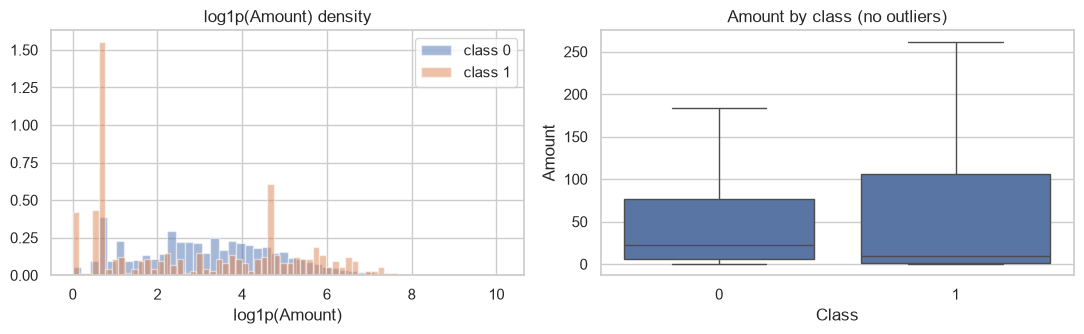

In [4]:
print(df.groupby('Class')['Amount'].describe()[['50%', 'mean', 'max']])
print('zero-amount rows by class:')
print(df.assign(zero=df.Amount.eq(0)).groupby('Class')['zero'].sum())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for k, g in df.groupby('Class'):
    ax[0].hist(np.log1p(g.Amount), bins=50, density=True, alpha=0.5, label=f'class {k}')
ax[0].set_title('log1p(Amount) density'); ax[0].set_xlabel('log1p(Amount)'); ax[0].legend()
sns.boxplot(data=df, x='Class', y='Amount', showfliers=False, ax=ax[1]); ax[1].set_title('Amount by class (no outliers)')
plt.tight_layout()

## 4. Time — diurnal fraud rhythm

00-04h    4.804
04-08h    3.990
08-12h    1.444
12-16h    1.301
16-20h    1.577
20-24h    1.052
Name: Class, dtype: float64

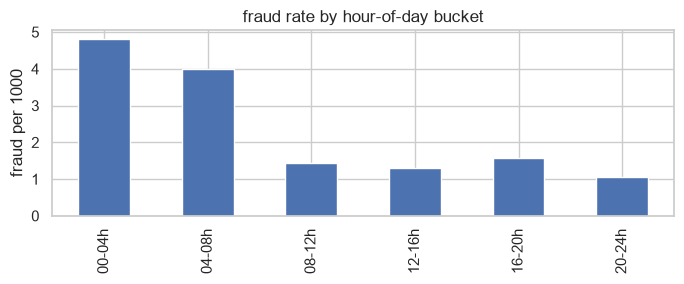

In [5]:
df['hour'] = (df['Time'] / 3600) % 24
rate = df.groupby((df.hour // 4).astype(int))['Class'].mean() * 1000
rate.index = [f'{h*4:02d}-{h*4+4:02d}h' for h in rate.index]
ax = rate.plot(kind='bar', figsize=(7, 3)); ax.set_ylabel('fraud per 1000'); ax.set_title('fraud rate by hour-of-day bucket')
plt.tight_layout(); rate.round(3)

## 5. Single-feature separation (which V's carry signal)

In [6]:
feats = [c for c in df.columns if c.startswith('V')] + ['Amount']
sep = pd.DataFrame({
    'roc_auc': {c: roc_auc_score(y, df[c]) for c in feats},
    'ap': {c: max(average_precision_score(y, df[c]), average_precision_score(y, -df[c])) for c in feats},
})
sep['abs_auc'] = (sep['roc_auc'] - 0.5).abs()
sep.sort_values('abs_auc', ascending=False).head(12).round(3)

,roc_auc,ap,abs_auc
V14,0.051,0.617,0.449
V4,0.938,0.205,0.438
V12,0.063,0.580,0.437
V11,0.918,0.495,0.418
V10,0.086,0.560,0.414
V3,0.088,0.228,0.412
V2,0.855,0.119,0.355
V16,0.153,0.475,0.347
V9,0.156,0.335,0.344
V7,0.164,0.196,0.336


## 6. Correlations among the top separators

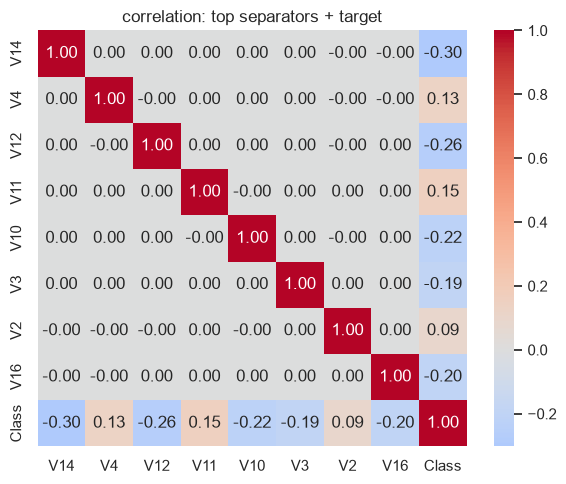

In [7]:
top = sep.sort_values('abs_auc', ascending=False).head(8).index.tolist()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[top + ['Class']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('correlation: top separators + target'); plt.tight_layout()

## Findings
See `reports/EDA_FINDINGS.md`. Headlines: 0.173% positive (AP floor 0.0017);
no missing values, 1,081 duplicates; fraud amounts skew small; fraud rate ~3-5x
higher 00:00-08:00; V14/V4/V12/V11/V10/V17 are the strongest single separators.